In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [154]:
df = pd.read_csv(r"insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [155]:

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [156]:
df['sex'].value_counts()


sex
male      676
female    662
Name: count, dtype: int64

In [157]:
df['smoker'].value_counts()


smoker
no     1064
yes     274
Name: count, dtype: int64

In [158]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

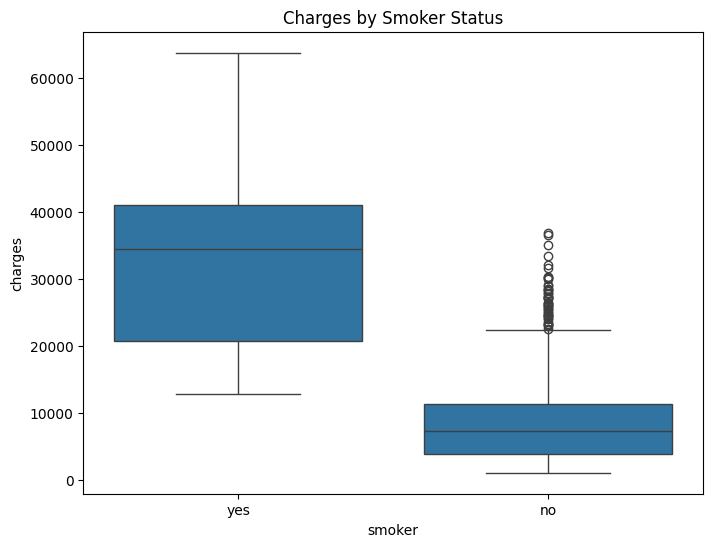

In [159]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status')
plt.show()

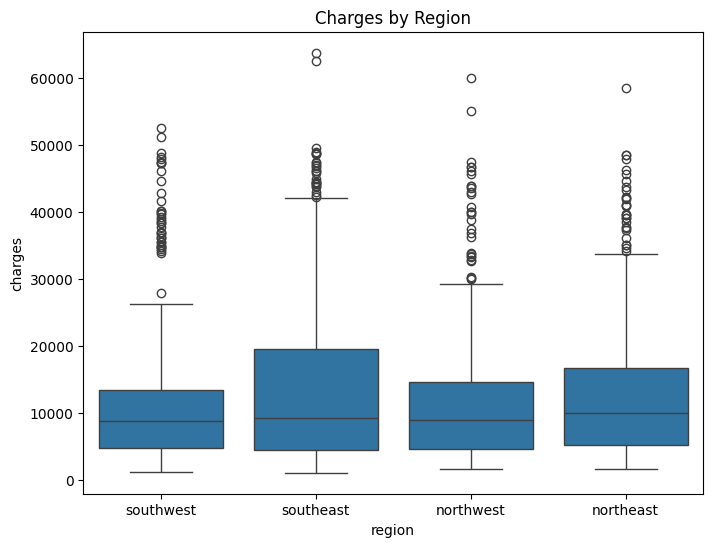

In [160]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()

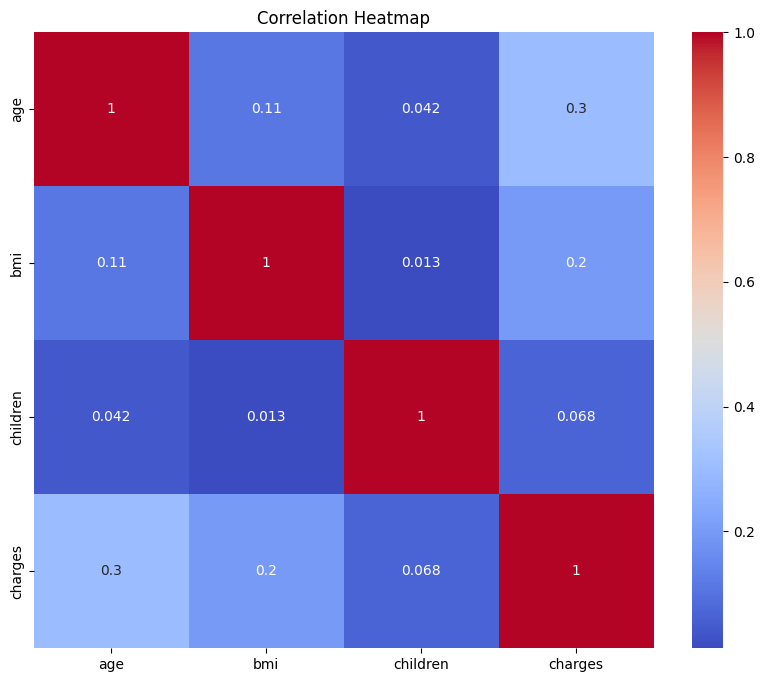

In [161]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [162]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [163]:
df_cleaned = df.copy()
df_cleaned['sex'] = df['sex'].map({'female': 1, 'male': 0})
df_cleaned['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'], drop_first=True)
df_cleaned.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [164]:

df_cleaned.rename(columns={
    'sex' :'is_female',
    'smoker': 'is_smoker'
                          },inplace = True)

In [165]:
df_cleaned = df_cleaned.astype('int')

In [166]:
df_cleaned.drop_duplicates(inplace = True)
df_cleaned.shape
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


In [167]:
# Categorize BMI into bins
bins = [0, 18.5, 24.9, 29.9, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'], bins=bins, labels=labels)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


bmi_category
Obese          697
Overweight     381
Normal         218
Underweight     24
Name: count, dtype: int64


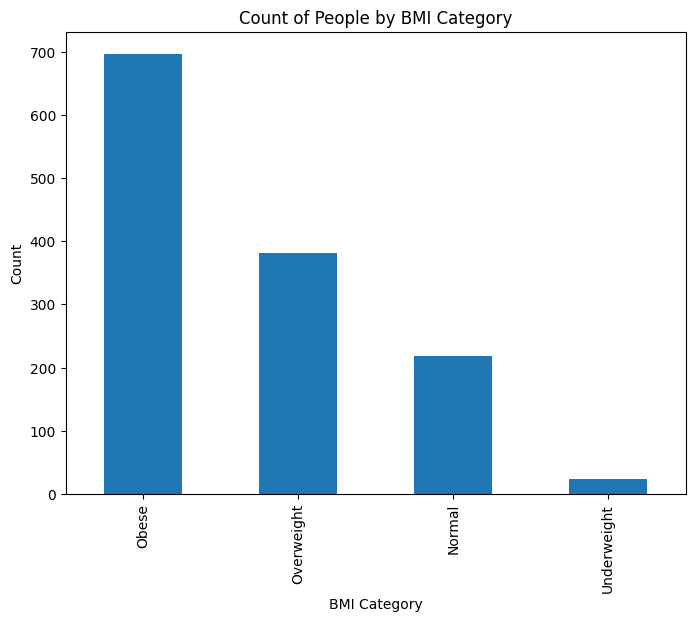

In [168]:
# Count the number of people in each BMI category
bmi_counts = df_cleaned['bmi_category'].value_counts()
print(bmi_counts)

# Plot the counts
plt.figure(figsize=(8, 6))
bmi_counts.plot(kind='bar')
plt.title('Count of People by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.show()

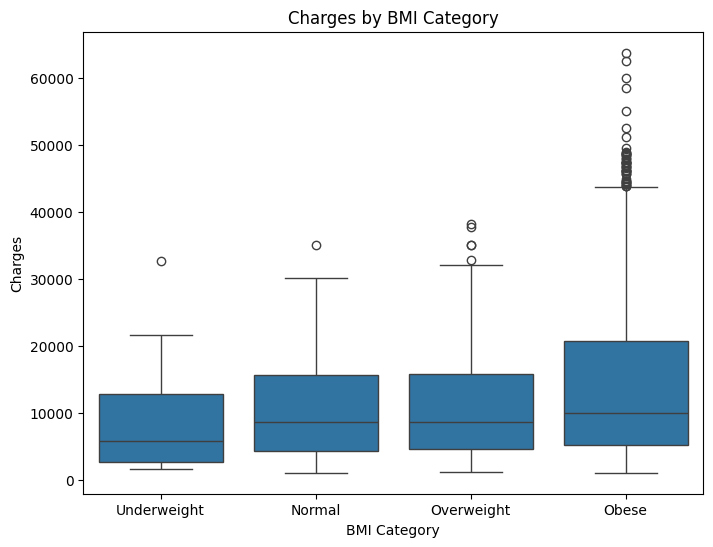

In [169]:
# Relation between BMI categories and charges
plt.figure(figsize=(8, 6))
sns.boxplot(x='bmi_category', y='charges', data=df_cleaned)
plt.title('Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Charges')
plt.show()


In [170]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

In [171]:
df_cleaned = df_cleaned.astype(int)

In [172]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [173]:
from sklearn.preprocessing import StandardScaler

# Scale the numerical features
scaler = StandardScaler()
columns_to_scale = ['age', 'bmi', 'children']
df_cleaned[columns_to_scale] = scaler.fit_transform(df_cleaned[columns_to_scale])
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.454322,1,-0.516878,-0.914990,1,16884,0,0,1,0,1,0
1,-1.525928,0,0.462938,-0.086604,0,1725,0,1,0,0,0,1
2,-0.809861,0,0.462938,1.570168,0,4449,0,1,0,0,0,1
3,-0.451828,0,-1.333391,-0.914990,0,21984,1,0,0,1,0,0
4,-0.523434,0,-0.353575,-0.914990,0,3866,1,0,0,0,1,0


In [174]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [175]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787241
0,age,0.292371
10,bmi_category_Obese,0.202864
1,bmi,0.198619
6,region_southeast,0.075526
2,children,0.061763
5,region_northwest,-0.039047
7,region_southwest,-0.045216
3,is_female,-0.056829
8,bmi_category_Normal,-0.103333


In [176]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,824.615428,0.0,Reject Null (Keep Feature)
region_southeast,16.51169,0.00089,Reject Null (Keep Feature)
is_female,10.726237,0.013302,Reject Null (Keep Feature)
bmi_category_Obese,8.423443,0.038025,Reject Null (Keep Feature)
region_southwest,5.160621,0.160406,Accept Null (Drop Feature)
bmi_category_Overweight,4.202494,0.240412,Accept Null (Drop Feature)
bmi_category_Normal,2.835212,0.417736,Accept Null (Drop Feature)
region_northwest,1.164903,0.761434,Accept Null (Drop Feature)


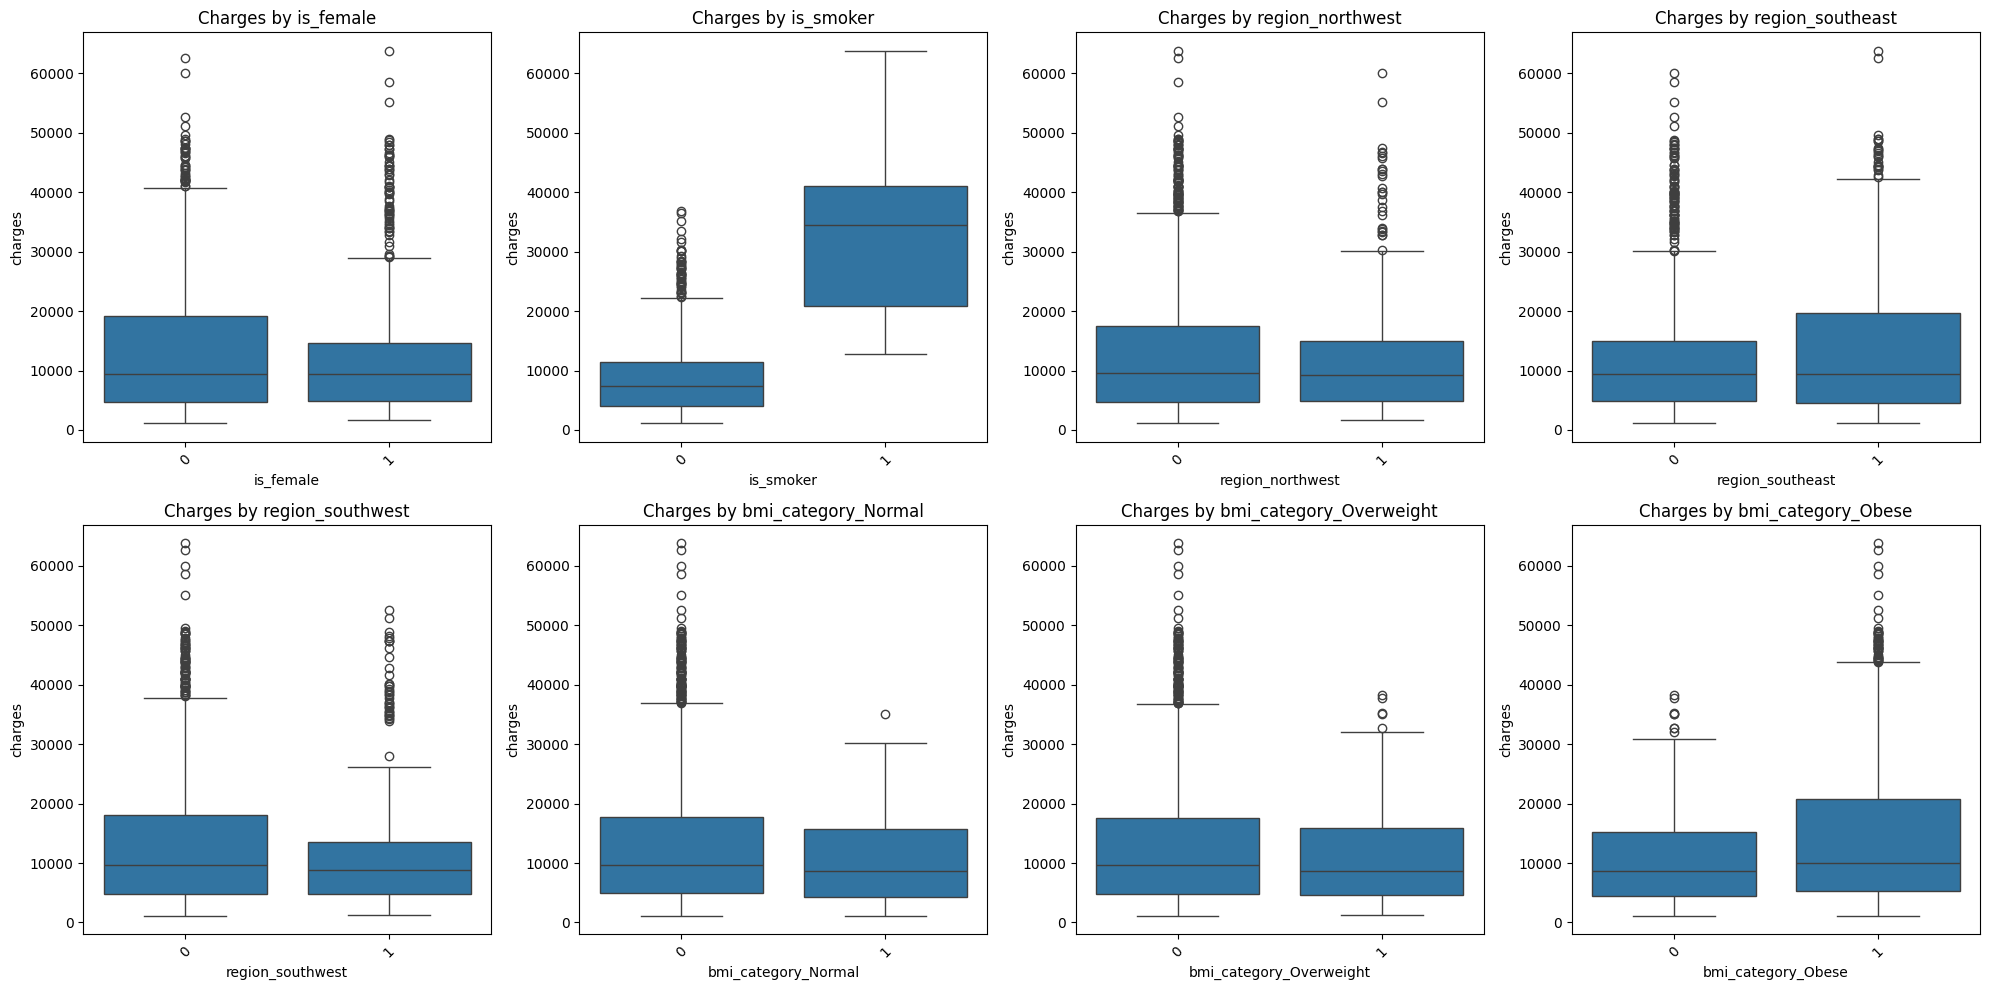

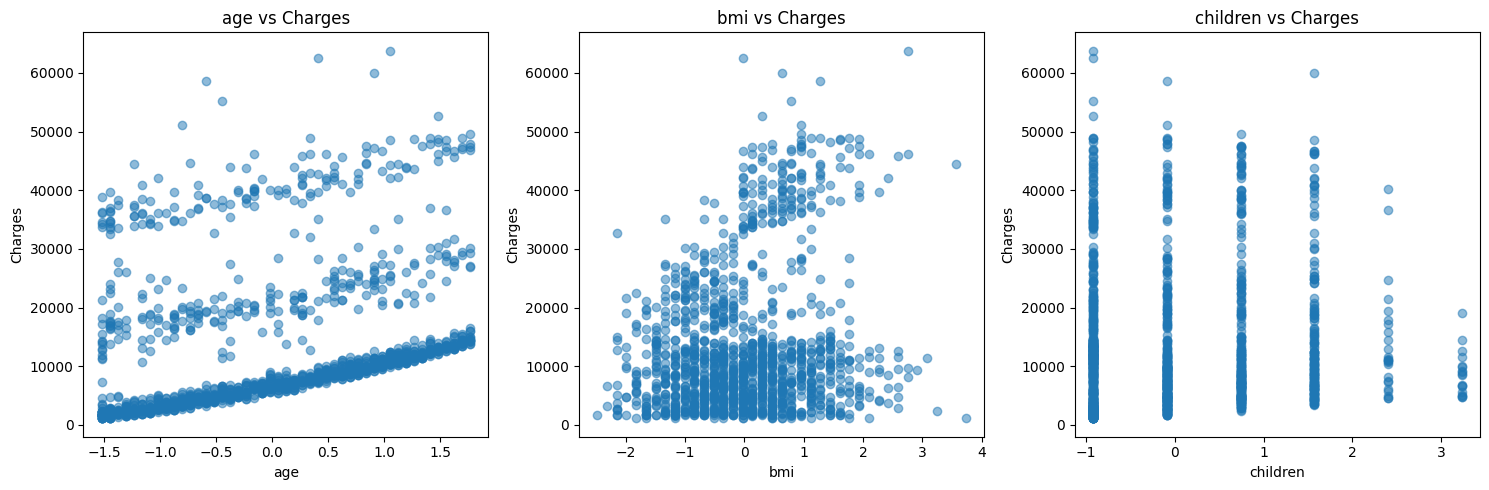

In [182]:
# Visual evaluation: Boxplots for categorical features vs charges
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='charges', data=df_cleaned, ax=axes[i])
    axes[i].set_title(f'Charges by {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Scatter plots for numerical features vs charges
numerical_features = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(numerical_features):
    axes[i].scatter(df_cleaned[col], df_cleaned['charges'], alpha=0.5)
    axes[i].set_title(f'{col} vs Charges')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Charges')

plt.tight_layout()
plt.show()

In [177]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [180]:
print(final_df)
final_df.to_csv('final_insurance_data.csv', index=False)

           age  is_female       bmi  children  is_smoker  charges  \
0    -1.454322          1 -0.516878 -0.914990          1    16884   
1    -1.525928          0  0.462938 -0.086604          0     1725   
2    -0.809861          0  0.462938  1.570168          0     4449   
3    -0.451828          0 -1.333391 -0.914990          0    21984   
4    -0.523434          0 -0.353575 -0.914990          0     3866   
...        ...        ...       ...       ...        ...      ...   
1333  0.765487          0 -0.026970  1.570168          0    10600   
1334 -1.525928          1  0.136333 -0.914990          0     2205   
1335 -1.525928          1  0.952846 -0.914990          0     1629   
1336 -1.311108          1 -0.843483 -0.914990          0     2007   
1337  1.553161          1 -0.190272 -0.914990          1    29141   

      region_southeast  bmi_category_Obese  
0                    0                   0  
1                    1                   1  
2                    1              

In [181]:
from scipy.stats import f_oneway

# ANOVA for each categorical feature vs charges
anova_results = {}
alpha = 0.05

for col in cat_features:
    groups = [df_cleaned[df_cleaned[col] == val]['charges'] for val in df_cleaned[col].unique()]
    f_stat, p_val = f_oneway(*groups)
    decision = "Reject H0 (Means differ - Feature useful)" if p_val < alpha else "Fail to reject H0 (Means similar - Feature not useful)"
    anova_results[col] = {
        'f_stat': f_stat,
        'p_val': p_val,
        'decision': decision
    }

# Display results
print("ANOVA Test Results for Categorical Features vs Charges:")
for feature, result in anova_results.items():
    print(f"\n{feature}:")
    print(f"  F-Statistic: {result['f_stat']:.4f}")
    print(f"  P-value: {result['p_val']:.4f}")
    print(f"  Decision: {result['decision']}")

selected_features_anova = [k for k, v in anova_results.items() if v['p_val'] < alpha]
print(f"\nSelected Features (p < 0.05): {selected_features_anova}")

ANOVA Test Results for Categorical Features vs Charges:

is_female:
  F-Statistic: 4.2703
  P-value: 0.0390
  Decision: Reject H0 (Means differ - Feature useful)

is_smoker:
  F-Statistic: 2148.1250
  P-value: 0.0000
  Decision: Reject H0 (Means differ - Feature useful)

region_northwest:
  F-Statistic: 2.0126
  P-value: 0.1562
  Decision: Fail to reject H0 (Means similar - Feature not useful)

region_southeast:
  F-Statistic: 7.5612
  P-value: 0.0060
  Decision: Reject H0 (Means differ - Feature useful)

region_southwest:
  F-Statistic: 2.7002
  P-value: 0.1006
  Decision: Fail to reject H0 (Means similar - Feature not useful)

bmi_category_Normal:
  F-Statistic: 14.2251
  P-value: 0.0002
  Decision: Reject H0 (Means differ - Feature useful)

bmi_category_Overweight:
  F-Statistic: 20.4169
  P-value: 0.0000
  Decision: Reject H0 (Means differ - Feature useful)

bmi_category_Obese:
  F-Statistic: 56.5686
  P-value: 0.0000
  Decision: Reject H0 (Means differ - Feature useful)

Selected 